# NorthStar Urban Mobility Dataset Understanding and Cleaning




In [ ]:
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/s4ndddyy/northstar-urban-mobility-analytics/main/northstar_dataset/"

customers = pd.read_csv(BASE_URL + "customers.csv")
orders = pd.read_csv(BASE_URL + "orders.csv")
deliveries = pd.read_csv(BASE_URL + "deliveries.csv")
drivers = pd.read_csv(BASE_URL + "drivers.csv")
vehicles = pd.read_csv(BASE_URL + "vehicles.csv")
complaints = pd.read_csv(BASE_URL + "complaints.csv")
incidents = pd.read_csv(BASE_URL + "incidents.csv")
app_events = pd.read_csv(BASE_URL + "app_events.csv")
data_dictionary = pd.read_csv(BASE_URL + "data_dictionary.csv")
hubs = pd.read_csv(BASE_URL + "hubs.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


# Data Cleaning and Standardisation

In [ ]:
#Store all datasets in a dictionary for easier inspection

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events,
    "hubs": hubs
}

#Loop through each dataset and display basic structural information
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"{'='*50}")

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nData Types:")
    print(df.dtypes)

    print("\nSample Rows:")
    print(df.head())


DATASET: customers

Shape:
(650, 9)

Columns:
['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date', 'loyalty_score', 'app_engagement_score', 'preferred_channel', 'account_status']

Missing Values:
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

Data Types:
customer_id              object
age                       int64
home_zone                object
customer_type            object
signup_date              object
loyalty_score           float64
app_engagement_score    float64
preferred_channel        object
account_status           object
dtype: object

Sample Rows:
  customer_id  age  home_zone customer_type          signup_date  \
0       C0001   26      North           SME  2024-11-27 04:25:00   
1       C0002   61    AIRPORT      Consumer  2025-10-28 01:04:00   

In [ ]:
#Create clean copy of the datasets

customers_clean = customers.copy()
orders_clean = orders.copy()
deliveries_clean = deliveries.copy()
drivers_clean = drivers.copy()
vehicles_clean = vehicles.copy()
complaints_clean = complaints.copy()
incidents_clean = incidents.copy()
app_events_clean = app_events.copy()
hubs_clean = hubs.copy()

Several datasets contained inconsistent zone naming conventions.
Standardising these fields improves consistency across joins and operational analysis.

In [ ]:
#Function used to standardise zone values across datasets

def clean_zone(column):
    return (
        column.astype(str)
        .str.strip()
        .str.lower()
        .replace({
            'north': 'North',
            'south': 'South',
            'east': 'East',
            'west': 'West',
            'airport': 'Airport',
            'central': 'Central',
            'ctr': 'Central',
            'riverside': 'Riverside'
        })
        .str.title()
    )


#Apply the zone cleaning function to all relevant columns

customers_clean['home_zone'] = clean_zone(
    customers_clean['home_zone']
)

orders_clean['pickup_zone'] = clean_zone(
    orders_clean['pickup_zone']
)

orders_clean['dropoff_zone'] = clean_zone(
    orders_clean['dropoff_zone']
)

drivers_clean['base_zone'] = clean_zone(
    drivers_clean['base_zone']
)

vehicles_clean['assigned_zone'] = clean_zone(
    vehicles_clean['assigned_zone']
)

app_events_clean['zone_context'] = clean_zone(
    app_events_clean['zone_context']
)

hubs_clean['zone'] = clean_zone(
    hubs_clean['zone']
)

Date related columns are converted into datetime format to support:
- time based calculations,
- delivery duration analysis,
- operational trend analysis,
- timestamp comparisons.

In [ ]:
#Convert string based date columns into datetime format

customers_clean['signup_date'] = pd.to_datetime(
    customers_clean['signup_date']
)

orders_clean['order_created_at'] = pd.to_datetime(
    orders_clean['order_created_at']
)

deliveries_clean['dispatch_time'] = pd.to_datetime(
    deliveries_clean['dispatch_time']
)

deliveries_clean['delivery_completed_at'] = pd.to_datetime(
    deliveries_clean['delivery_completed_at']
)

complaints_clean['created_at'] = pd.to_datetime(
    complaints_clean['created_at']
)

incidents_clean['reported_at'] = pd.to_datetime(
    incidents_clean['reported_at']
)

app_events_clean['event_timestamp'] = pd.to_datetime(
    app_events_clean['event_timestamp']
)

Missing values were identified in several operational attributes. Appropriate strategies were applied depending on the type of data.
This ensures analytical consistency without removing operational records.

In [ ]:
#Handle missing values in operational datasets

# Customers
customers_clean['loyalty_score'] = customers_clean[
    'loyalty_score'
].fillna(
    customers_clean['loyalty_score'].median()
)

customers_clean['preferred_channel'] = customers_clean[
    'preferred_channel'
].fillna('Unknown')


# Deliveries
deliveries_clean['customer_rating_post_delivery'] = deliveries_clean[
    'customer_rating_post_delivery'
].fillna(
    deliveries_clean['customer_rating_post_delivery'].median()
)


# Vehicles
vehicles_clean['battery_health_pct'] = vehicles_clean[
    'battery_health_pct'
].fillna(
    vehicles_clean['battery_health_pct'].median()
)

# Feature Engineering and Operational Metrics
Additional analytical features were created to support operational analysis and risk profiling.
These engineered features help identify delivery efficiency, operational risk,complaint behaviour and delivery performance trends.

In [ ]:
#Create additional operational metrics for analysis

#Delivery duration
deliveries_clean['delivery_duration_hours'] = (
    deliveries_clean['delivery_completed_at']
    - deliveries_clean['dispatch_time']
).dt.total_seconds() / 3600


#High risk delivery flag
deliveries_clean['high_risk_delivery'] = (
    (deliveries_clean['manual_route_override_count'] >= 2) |
    (deliveries_clean['proof_of_completion_missing'] == 1)
).astype(int)


#Customer complaint frequency
complaint_counts = complaints_clean.groupby(
    'customer_id'
).size()

customers_clean['complaint_count'] = customers_clean[
    'customer_id'
].map(
    complaint_counts
).fillna(0)

# Integrated Operational Data View
The cleaned datasets are merged to create an operational dataset. This enables cross functional analysis between deliveries, customers, drivers,vehicles and
operational performance indicators.

This dataset is later used for analytics and visualisation.

In [ ]:
#Merge delivery records with related order information
merged_data = deliveries_clean.merge(
    orders_clean,
    on='order_id',
    how='left'
)

#Attach customer information to each operational record
merged_data = merged_data.merge(
    customers_clean,
    on='customer_id',
    how='left'
)

#Merge driver performance and profile data
merged_data = merged_data.merge(
    drivers_clean,
    on='driver_id',
    how='left'
)

#Merge vehicle operational and maintenance information
merged_data = merged_data.merge(
    vehicles_clean,
    on='vehicle_id',
    how='left'
)

print("Merged Dataset Shape:")
print(merged_data.shape)

merged_data.head()

Merged Dataset Shape:
(950, 48)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,4.75,Morning,1,EV,Central,2024-06-09 16:18:00,78.4,29849,Active,v2.2
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,4.61,Evening,1,Diesel,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,4.38,Flexible,1,Diesel,East,2025-12-09 16:47:00,55.9,15278,Active,v2.2
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,4.19,Morning,1,Hybrid,East,2025-06-05 13:40:00,83.3,85635,Active,v2.1
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,4.33,Morning,1,EV,Riverside,2025-05-24 09:58:00,94.2,210683,InRepair,v2.0


# Delivery Performance Analysis
This section evaluates delivery performance across different delivery statuses.


In [ ]:
delivery_analysis = merged_data.groupby('delivery_status').agg({
    'delivery_duration_hours': 'mean',
    'manual_route_override_count': 'mean',
    'fuel_or_charge_cost': 'mean',
    'customer_rating_post_delivery': 'mean'
}).round(2)

delivery_analysis

,delivery_duration_hours,manual_route_override_count,fuel_or_charge_cost,customer_rating_post_delivery
delivery_status,,,,
Delayed,13.51,1.07,13.14,3.14
Failed,17.78,1.04,13.15,3.06
OnTime,6.49,0.92,12.68,4.28


# Operational Performance and Delay Analysis
This analysis examines the distribution of delivery outcomes to identify the overall operational performance of the deliveries.

In [ ]:
delivery_status_counts = merged_data['delivery_status'].value_counts()

print(delivery_status_counts)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


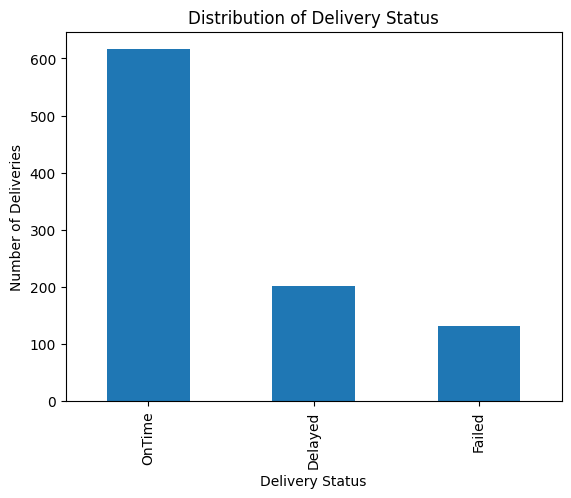

In [ ]:
import matplotlib.pyplot as plt

delivery_status_counts.plot(
    kind='bar'
)

plt.title('Distribution of Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Deliveries')

plt.show()

# Manual Route Override Analysis
This analysis compares override frequency across delivery outcomes.

In [ ]:
override_analysis = merged_data.groupby(
    'delivery_status'
)['manual_route_override_count'].mean().round(2)

print(override_analysis)

delivery_status
Delayed    1.07
Failed     1.04
OnTime     0.92
Name: manual_route_override_count, dtype: float64


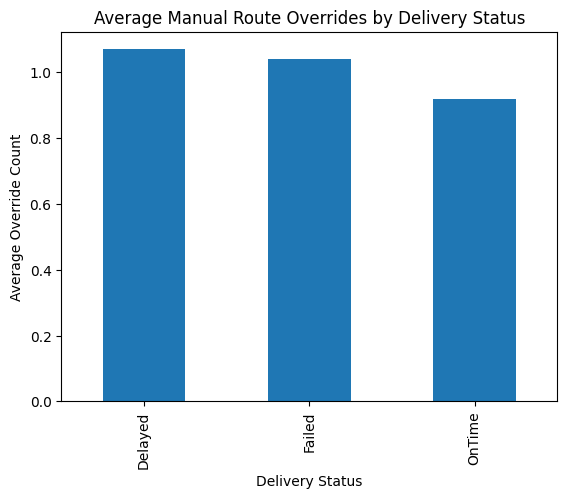

In [ ]:
override_analysis.plot(kind='bar')

plt.title('Average Manual Route Overrides by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Override Count')

plt.show()

# Complaint and Delivery Failure Analysis
Customer complaints are analysed alongside delivery outcomes to identify whether failed or delayed deliveries result in higher complaints or compensation.

In [ ]:
complaint_delivery_merge = complaints_clean.merge(
    orders_clean,
    on='order_id',
    how='left'
)

complaint_delivery_merge = complaint_delivery_merge.merge(
    deliveries_clean,
    on='order_id',
    how='left'
)

complaint_summary = complaint_delivery_merge.groupby(
    'delivery_status'
).agg({
    'complaint_id': 'count',
    'compensation_amount': 'mean',
    'resolution_days': 'mean'
}).round(2)

complaint_summary

,complaint_id,compensation_amount,resolution_days
delivery_status,,,
Delayed,48,18.36,7.62
Failed,35,25.47,9.66
OnTime,149,19.18,7.60


# Geographic Hotspot and Zone Performance Analysis

In [ ]:
zone_analysis = merged_data.groupby(
    'pickup_zone'
).agg({
    'delivery_duration_hours': 'mean',
    'fuel_or_charge_cost': 'mean',
    'delivery_id': 'count',
    'customer_rating_post_delivery': 'mean'
}).round(2)

zone_analysis = zone_analysis.rename(columns={
    'delivery_id': 'total_deliveries'
})

zone_analysis.sort_values(
    by='delivery_duration_hours',
    ascending=False
)

,delivery_duration_hours,fuel_or_charge_cost,total_deliveries,customer_rating_post_delivery
pickup_zone,,,,
Central,10.53,12.12,174,3.56
Riverside,10.04,12.39,119,3.87
East,9.64,12.57,156,3.91
North,9.19,12.07,135,3.90
West,9.09,11.94,114,3.90
Airport,8.98,17.08,113,3.99
South,8.98,12.48,139,4.05


In [ ]:
zone_failure_rates = merged_data.pivot_table(
    index='pickup_zone',
    columns='delivery_status',
    values='delivery_id',
    aggfunc='count',
    fill_value=0
)

zone_failure_rates

delivery_status,Delayed,Failed,OnTime
pickup_zone,,,
Airport,31,12,70
Central,51,33,90
East,31,19,106
North,21,22,92
Riverside,25,18,76
South,22,14,103
West,21,14,79


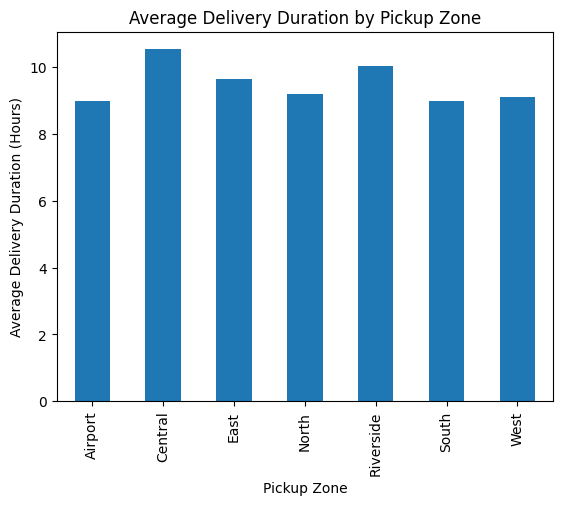

In [ ]:
zone_analysis['delivery_duration_hours'].plot(
    kind='bar'
)

plt.title('Average Delivery Duration by Pickup Zone')
plt.xlabel('Pickup Zone')
plt.ylabel('Average Delivery Duration (Hours)')

plt.show()

# Driver Performance Profiling

In [ ]:
driver_analysis = merged_data.groupby(
    'driver_id'
).agg({
    'delivery_id': 'count',
    'delivery_duration_hours': 'mean',
    'manual_route_override_count': 'mean',
    'customer_rating_post_delivery': 'mean',
    'fuel_or_charge_cost': 'mean'
}).round(2)

driver_analysis = driver_analysis.rename(columns={
    'delivery_id': 'total_deliveries'
})

driver_analysis.sort_values(
    by='customer_rating_post_delivery'
).head(10)

,total_deliveries,delivery_duration_hours,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
driver_id,,,,,
D063,3,21.73,0.33,2.37,10.40
D111,4,12.47,0.50,2.64,11.40
D076,4,16.58,1.00,2.67,14.47
D141,9,13.33,0.78,2.93,10.97
D165,6,15.77,1.33,2.98,11.04
D147,2,2.75,1.00,3.10,19.95
D021,2,2.58,2.50,3.10,11.68
D091,6,12.14,0.17,3.13,10.96
D137,4,9.82,1.00,3.14,13.03


In [ ]:
driver_analysis['high_risk_driver'] = (
    (driver_analysis['manual_route_override_count'] > 1.2) |
    (driver_analysis['customer_rating_post_delivery'] < 3.5)
)

driver_analysis['high_risk_driver'].value_counts()

,count
high_risk_driver,
False,103
True,67


# Maintenance Analysis

In [ ]:
vehicle_analysis = merged_data.groupby(
    'vehicle_type'
).agg({
    'delivery_duration_hours': 'mean',
    'fuel_or_charge_cost': 'mean',
    'battery_health_pct': 'mean',
    'manual_route_override_count': 'mean'
}).round(2)

vehicle_analysis

,delivery_duration_hours,fuel_or_charge_cost,battery_health_pct,manual_route_override_count
vehicle_type,,,,
CargoVan,9.54,12.84,72.08,0.97
Diesel,10.18,12.85,71.21,0.90
EV,9.23,12.93,81.98,0.96
Hybrid,9.62,12.72,77.99,1.02


In [ ]:
maintenance_analysis = merged_data.groupby(
    'maintenance_status'
).agg({
    'delivery_duration_hours': 'mean',
    'customer_rating_post_delivery': 'mean',
    'fuel_or_charge_cost': 'mean'
}).round(2)

maintenance_analysis

,delivery_duration_hours,customer_rating_post_delivery,fuel_or_charge_cost
maintenance_status,,,
Active,8.86,3.95,12.87
InRepair,11.32,3.64,12.90
Scheduled,9.05,3.93,12.63


# Mobile Platform and Application Analytics

In [ ]:
app_event_analysis = app_events_clean.groupby(
    'event_type'
).agg({
    'api_latency_ms': 'mean',
    'success_flag': 'mean',
    'event_id': 'count'
}).round(2)

app_event_analysis = app_event_analysis.rename(columns={
    'event_id': 'event_count'
})

app_event_analysis

,api_latency_ms,success_flag,event_count
event_type,,,
cancel_attempt,417.14,1.00,28
chat_escalated,478.13,0.50,38
chat_opened,478.33,1.00,88
delivery_instruction_update,496.29,1.00,75
eta_refresh,452.15,1.00,105
payment_retry,472.68,0.72,69
search_route,456.51,1.00,99
track_order,460.71,1.00,138


In [ ]:
zone_app_performance = app_events_clean.groupby(
    'zone_context'
).agg({
    'api_latency_ms': 'mean',
    'success_flag': 'mean'
}).round(2)

zone_app_performance.sort_values(
    by='api_latency_ms',
    ascending=False
)

,api_latency_ms,success_flag
zone_context,,
Airport,606.08,0.95
Central,505.06,0.92
North,444.28,0.92
East,434.71,0.97
South,428.47,0.96
West,426.84,0.95
Riverside,420.94,0.91


# Correlation and Relationship Analysis

In [ ]:
import seaborn as sns

correlation_columns = [
    'delivery_duration_hours',
    'manual_route_override_count',
    'fuel_or_charge_cost',
    'customer_rating_post_delivery',
    'battery_health_pct',
    'odometer_km',
    'driver_rating',
    'training_score'
]

correlation_matrix = merged_data[
    correlation_columns
].corr()

correlation_matrix

,delivery_duration_hours,manual_route_override_count,fuel_or_charge_cost,customer_rating_post_delivery,battery_health_pct,odometer_km,driver_rating,training_score
delivery_duration_hours,1.000000,-0.013711,0.049378,-0.304449,-0.011541,0.032836,-0.069394,0.069068
manual_route_override_count,-0.013711,1.000000,0.098690,-0.059817,-0.000909,-0.002011,-0.024360,0.009640
fuel_or_charge_cost,0.049378,0.098690,1.000000,-0.057365,-0.002393,-0.009342,-0.000761,-0.018228
customer_rating_post_delivery,-0.304449,-0.059817,-0.057365,1.000000,-0.011077,-0.024651,0.097451,0.002259
battery_health_pct,-0.011541,-0.000909,-0.002393,-0.011077,1.000000,0.066344,-0.002123,0.016632
odometer_km,0.032836,-0.002011,-0.009342,-0.024651,0.066344,1.000000,-0.032544,-0.035905
driver_rating,-0.069394,-0.024360,-0.000761,0.097451,-0.002123,-0.032544,1.000000,-0.043136
training_score,0.069068,0.009640,-0.018228,0.002259,0.016632,-0.035905,-0.043136,1.000000


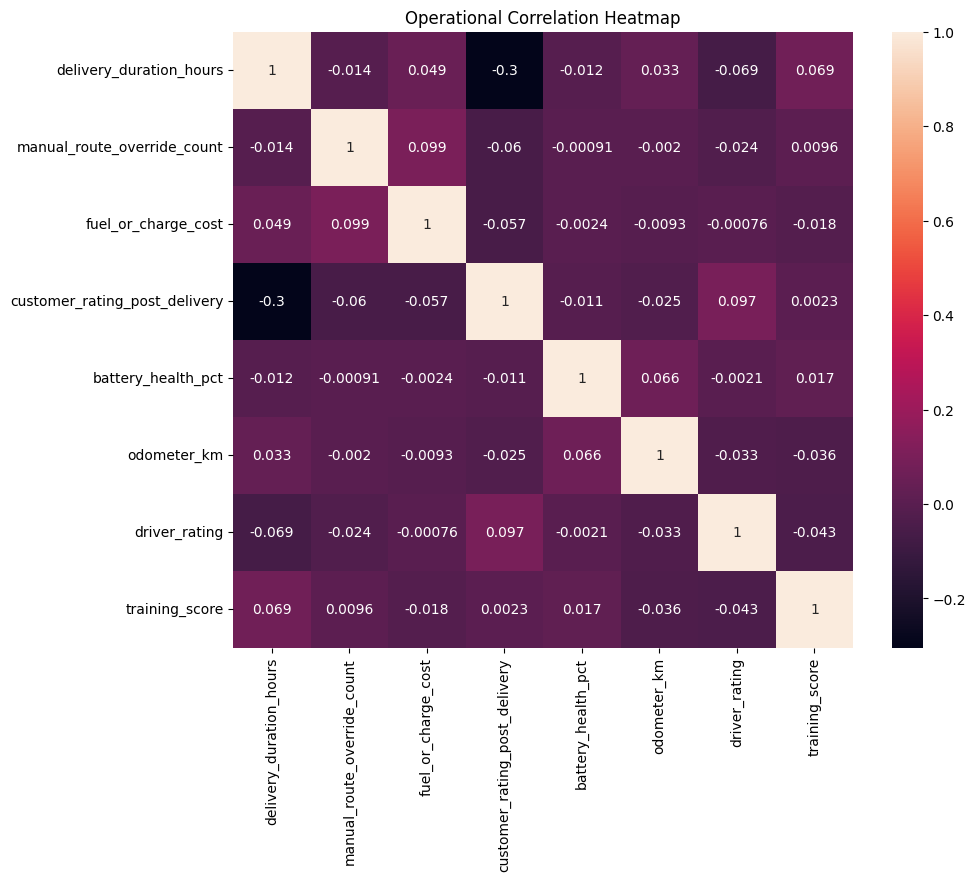

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title('Operational Correlation Heatmap')

plt.show()

# Operational Visualisations

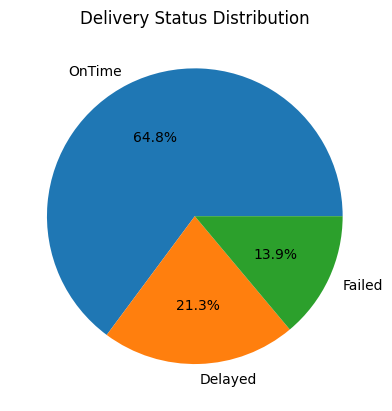

In [ ]:
merged_data['delivery_status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Delivery Status Distribution')

plt.ylabel('')

plt.show()

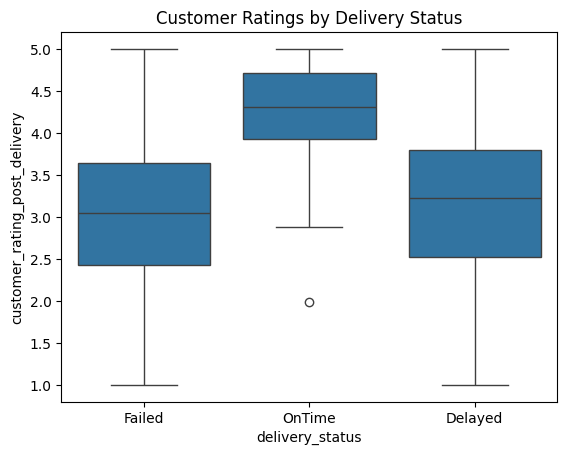

In [ ]:
sns.boxplot(
    x='delivery_status',
    y='customer_rating_post_delivery',
    data=merged_data
)

plt.title('Customer Ratings by Delivery Status')

plt.show()

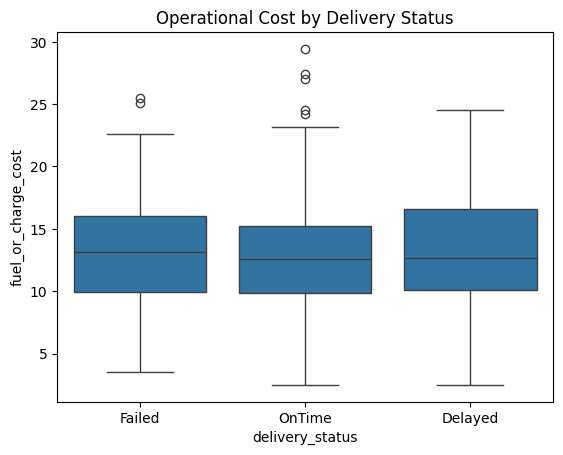

In [ ]:
sns.boxplot(
    x='delivery_status',
    y='fuel_or_charge_cost',
    data=merged_data
)

plt.title('Operational Cost by Delivery Status')

plt.show()

# Exporting Cleaned Datasets

In [ ]:
customers_clean.to_csv("customers_clean.csv", index=False)
orders_clean.to_csv("orders_clean.csv", index=False)
deliveries_clean.to_csv("deliveries_clean.csv", index=False)
drivers_clean.to_csv("drivers_clean.csv", index=False)
vehicles_clean.to_csv("vehicles_clean.csv", index=False)
complaints_clean.to_csv("complaints_clean.csv", index=False)
incidents_clean.to_csv("incidents_clean.csv", index=False)
app_events_clean.to_csv("app_events_clean.csv", index=False)
hubs_clean.to_csv("hubs_clean.csv", index=False)

print("Cleaned datasets exported successfully.")

Cleaned datasets exported successfully.
